# Individual Task 2, Part 2: Deliberation on Task 1
Re-evaluates the Task 1 models (Decision Tree and SVR) on the AEMO VIC1 and UCI household datasets.

1. Evaluation strategy: shuffled split vs cross-validation vs time-ordered validation
2. Learning curves
3. Bias analysis with Microsoft Fairlearn
4. Exports figures and tables to `outputs/` for the report and appendix

Uses the same data paths as the Task 1 notebook.

In [ ]:
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from fairlearn.metrics import MetricFrame, count

pd.set_option('display.max_columns', None)
os.makedirs('outputs', exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5
# RBF SVR scales roughly quadratically with rows. Training sets above this size are
# randomly subsampled 
SVR_MAX_TRAIN = 10000

def rmse(y, p):
    return mean_squared_error(y, p) ** 0.5

def mean_error(y, p):
    # signed error: positive = model over-forecasts, negative = under-forecasts
    return float(np.mean(np.asarray(p) - np.asarray(y)))

def make_models():
    return {
        'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'SVM': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    }

def cap_rows(idx, model_name, rng):
    if model_name == 'SVM' and len(idx) > SVR_MAX_TRAIN:
        return np.sort(rng.choice(idx, SVR_MAX_TRAIN, replace=False))
    return idx

## 1. Load data (same steps as Task 1)

In [2]:
aemo_files = glob.glob('data/aemo/*.csv')
aemo = pd.concat([pd.read_csv(f) for f in aemo_files], ignore_index=True)
aemo['SETTLEMENTDATE'] = pd.to_datetime(aemo['SETTLEMENTDATE'])
aemo = aemo.sort_values('SETTLEMENTDATE').reset_index(drop=True)
aemo['hour'] = aemo['SETTLEMENTDATE'].dt.hour
aemo['dayofweek'] = aemo['SETTLEMENTDATE'].dt.dayofweek
aemo['month'] = aemo['SETTLEMENTDATE'].dt.month
aemo['is_weekend'] = (aemo['dayofweek'] >= 5).astype(int)
print('AEMO rows:', len(aemo))

AEMO rows: 52416


In [ ]:
household = pd.read_csv('data/household/household_power_consumption.txt',
                        sep=';', low_memory=False, na_values=['?'])
household['Datetime'] = pd.to_datetime(household['Date'] + ' ' + household['Time'],
                                       format='%d/%m/%Y %H:%M:%S')
household = household.sort_values('Datetime').reset_index(drop=True)
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_cols:
    household[col] = pd.to_numeric(household[col], errors='coerce')

# where do the missing readings fall? (dataset bias check)
missing = household['Global_active_power'].isna()
missing_by_month = missing.groupby(household['Datetime'].dt.to_period('M')).mean() * 100
print(f'Overall missing: {missing.mean()*100:.2f}%')
print('Months with the most missing data (%):')
print(missing_by_month.sort_values(ascending=False).head(8).round(2))

household = household.dropna(subset=numeric_cols).reset_index(drop=True)
household_hourly = (household.set_index('Datetime')[numeric_cols]
                    .resample('h').mean().dropna().reset_index())
household_hourly['hour'] = household_hourly['Datetime'].dt.hour
household_hourly['dayofweek'] = household_hourly['Datetime'].dt.dayofweek
household_hourly['month'] = household_hourly['Datetime'].dt.month
household_hourly['is_weekend'] = (household_hourly['dayofweek'] >= 5).astype(int)
print('Household hourly rows:', len(household_hourly))

Overall missing: 1.25%
Months with the most missing data (%):
Datetime
2010-08    16.19
2010-09    12.12
2007-04     8.62
2009-06     7.65
2010-01     7.01
2010-03     4.54
2009-08     2.00
2007-07     0.29
Freq: M, Name: Global_active_power, dtype: float64
Household hourly rows: 34168


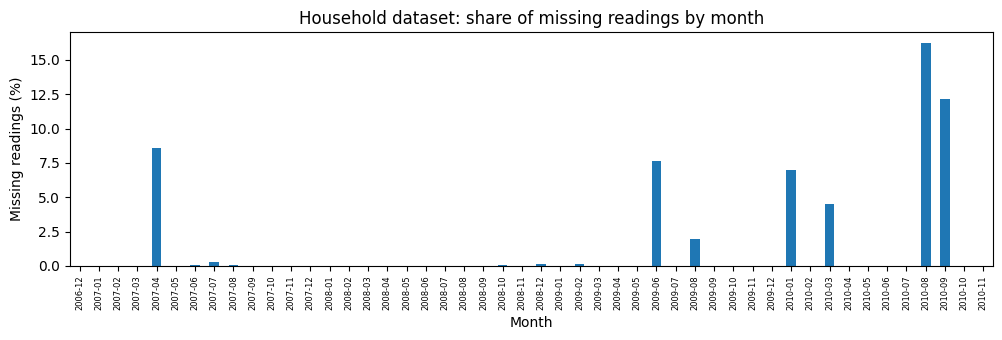

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
missing_by_month.plot(kind='bar', ax=ax)
ax.set_title('Household dataset: share of missing readings by month')
ax.set_ylabel('Missing readings (%)')
ax.set_xlabel('Month')
ax.tick_params(axis='x', labelsize=6)
plt.tight_layout(); plt.savefig('outputs/household_missing_by_month.png', dpi=200); plt.show()

## 2. Evaluation strategy
Each experiment set: (dataframe, features, target). AEMO is also run without `RRP`, because
price is set in the same interval as demand and would not be known when forecasting ahead.

Strategies compared:
- **Task 1 shuffled 80/20 split** (reproduces the original numbers)
- **Shuffled 5-fold CV** (standard CV, still ignores time order)
- **TimeSeriesSplit 5-fold** (train on the past, validate on the next block)
- **Chronological 80/20 holdout** (first 80% train, final 20% test)

In [5]:
experiments = {
    'AEMO (with RRP)':    (aemo, ['hour', 'dayofweek', 'month', 'is_weekend', 'RRP'], 'TOTALDEMAND'),
    'AEMO (without RRP)': (aemo, ['hour', 'dayofweek', 'month', 'is_weekend'], 'TOTALDEMAND'),
    'Household':          (household_hourly, ['hour', 'dayofweek', 'month', 'is_weekend'], 'Global_active_power'),
}

def evaluate_split(model_name, model, X, y, train_idx, test_idx, rng):
    tr = cap_rows(train_idx, model_name, rng)
    m = clone(model).fit(X.iloc[tr], y.iloc[tr])
    p = m.predict(X.iloc[test_idx])
    return rmse(y.iloc[test_idx], p), mean_absolute_error(y.iloc[test_idx], p)

rows = []
for exp_name, (df, feats, target) in experiments.items():
    X, y = df[feats], df[target]
    n = len(df)
    idx_all = np.arange(n)
    tr_s, te_s = train_test_split(idx_all, test_size=0.2, random_state=RANDOM_STATE)
    cut = int(n * 0.8)
    strategies = {
        'Task 1 shuffled 80/20': [(tr_s, te_s)],
        'Shuffled 5-fold CV': list(KFold(N_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(X)),
        'TimeSeriesSplit 5-fold': list(TimeSeriesSplit(N_SPLITS).split(X)),
        'Chronological 80/20': [(idx_all[:cut], idx_all[cut:])],
    }
    for model_name, model in make_models().items():
        for strat, splits in strategies.items():
            t0 = time.time(); rng = np.random.default_rng(RANDOM_STATE)
            scores = np.array([evaluate_split(model_name, model, X, y, a, b, rng) for a, b in splits])
            rows.append({'Experiment': exp_name, 'Model': model_name, 'Strategy': strat,
                         'RMSE mean': scores[:, 0].mean(), 'RMSE std': scores[:, 0].std(),
                         'MAE mean': scores[:, 1].mean(), 'Folds': len(splits)})
            print(f'{exp_name} | {model_name} | {strat}: RMSE={scores[:,0].mean():.3f} '
                  f'(±{scores[:,0].std():.3f})  [{time.time()-t0:.0f}s]')

cv_results = pd.DataFrame(rows).round(3)
cv_results.to_csv('outputs/evaluation_strategies.csv', index=False)
cv_results

AEMO (with RRP) | Decision Tree | Task 1 shuffled 80/20: RMSE=406.107 (±0.000)  [1s]
AEMO (with RRP) | Decision Tree | Shuffled 5-fold CV: RMSE=412.707 (±5.925)  [1s]
AEMO (with RRP) | Decision Tree | TimeSeriesSplit 5-fold: RMSE=791.508 (±74.072)  [1s]
AEMO (with RRP) | Decision Tree | Chronological 80/20: RMSE=773.604 (±0.000)  [0s]
AEMO (with RRP) | SVM | Task 1 shuffled 80/20: RMSE=889.749 (±0.000)  [15s]
AEMO (with RRP) | SVM | Shuffled 5-fold CV: RMSE=893.253 (±8.082)  [61s]
AEMO (with RRP) | SVM | TimeSeriesSplit 5-fold: RMSE=1031.067 (±202.069)  [52s]
AEMO (with RRP) | SVM | Chronological 80/20: RMSE=1319.988 (±0.000)  [15s]
AEMO (without RRP) | Decision Tree | Task 1 shuffled 80/20: RMSE=565.367 (±0.000)  [0s]
AEMO (without RRP) | Decision Tree | Shuffled 5-fold CV: RMSE=568.927 (±7.429)  [1s]
AEMO (without RRP) | Decision Tree | TimeSeriesSplit 5-fold: RMSE=755.168 (±137.130)  [0s]
AEMO (without RRP) | Decision Tree | Chronological 80/20: RMSE=777.849 (±0.000)  [0s]
AEMO (wit

,Experiment,Model,Strategy,RMSE mean,RMSE std,MAE mean,Folds
0,AEMO (with RRP),Decision Tree,Task 1 shuffled 80/20,406.107,0.000,218.466,1
1,AEMO (with RRP),Decision Tree,Shuffled 5-fold CV,412.707,5.925,221.606,5
2,AEMO (with RRP),Decision Tree,TimeSeriesSplit 5-fold,791.508,74.072,571.238,5
3,AEMO (with RRP),Decision Tree,Chronological 80/20,773.604,0.000,621.946,1
4,AEMO (with RRP),SVM,Task 1 shuffled 80/20,889.749,0.000,665.874,1
5,AEMO (with RRP),SVM,Shuffled 5-fold CV,893.253,8.082,668.638,5
6,AEMO (with RRP),SVM,TimeSeriesSplit 5-fold,1031.067,202.069,782.799,5
7,AEMO (with RRP),SVM,Chronological 80/20,1319.988,0.000,1051.387,1
8,AEMO (without RRP),Decision Tree,Task 1 shuffled 80/20,565.367,0.000,389.746,1
9,AEMO (without RRP),Decision Tree,Shuffled 5-fold CV,568.927,7.429,392.387,5


**Note for the write-up:** if the shuffled strategies give clearly lower error than the
time-ordered ones, Task 1 over-estimated real forecasting performance. Also compare AEMO with and
without RRP to see how much of the Task 1 result depended on same-interval price.
If `SVR_MAX_TRAIN` capped any SVM runs, state that in the report.

## 3. Learning curves
TimeSeriesSplit folds. Within each training fold, the model is trained on the most recent
10% to 100% of that fold (so the gap to the validation block stays the same), then scored on
the validation block. SVM points above `SVR_MAX_TRAIN` rows are skipped.

AEMO (without RRP) | Decision Tree done [0s]
AEMO (without RRP) | SVM done [102s]
Household | Decision Tree done [0s]
Household | SVM done [75s]


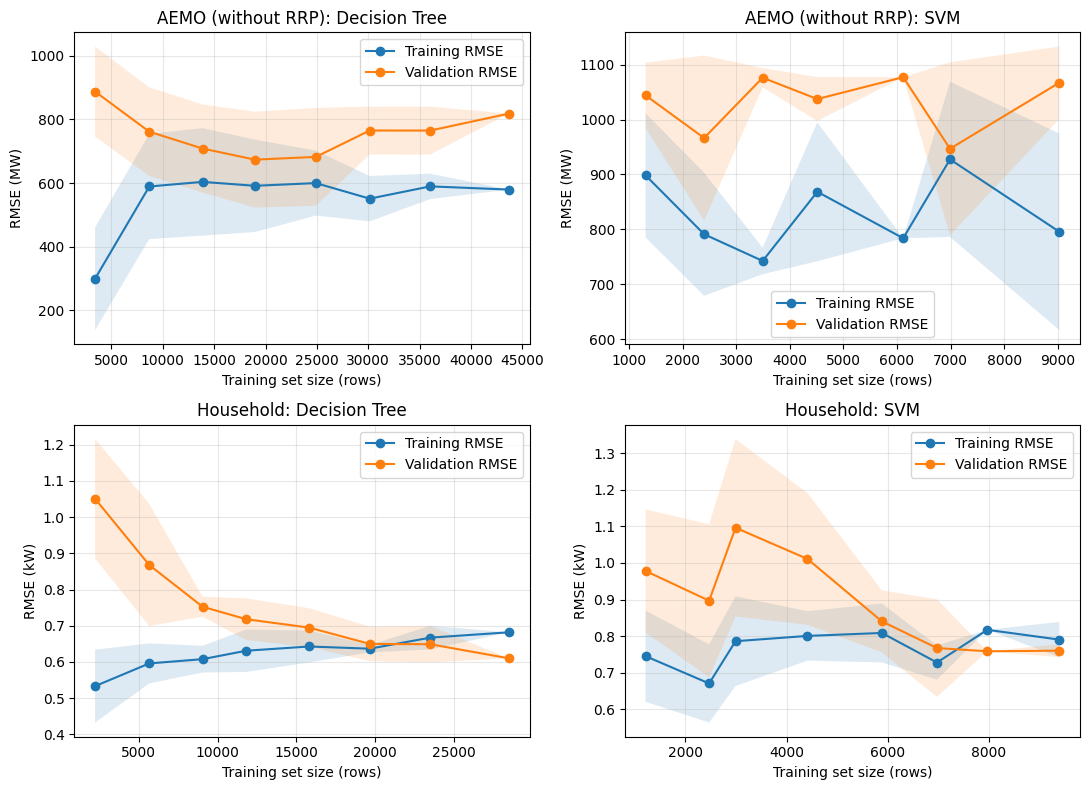

In [6]:
FRACTIONS = [0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]

def learning_curve_ts(df, feats, target, model_name, model, n_splits=N_SPLITS):
    X, y = df[feats], df[target]
    out = []
    for fold, (tr, va) in enumerate(TimeSeriesSplit(n_splits).split(X)):
        for f in FRACTIONS:
            k = max(int(len(tr) * f), 50)
            if model_name == 'SVM' and k > SVR_MAX_TRAIN:
                continue
            sub = tr[-k:]
            m = clone(model).fit(X.iloc[sub], y.iloc[sub])
            out.append({'fold': fold, 'train_size': k,
                        'train_rmse': rmse(y.iloc[sub], m.predict(X.iloc[sub])),
                        'val_rmse': rmse(y.iloc[va], m.predict(X.iloc[va]))})
    # fold sizes differ, so bin by fraction position and average
    res = pd.DataFrame(out)
    return res.groupby(pd.cut(res['train_size'], bins=8)).agg(
        train_size=('train_size', 'mean'), train_rmse=('train_rmse', 'mean'),
        train_std=('train_rmse', 'std'), val_rmse=('val_rmse', 'mean'),
        val_std=('val_rmse', 'std')).dropna(subset=['train_size'])

lc_exps = ['AEMO (without RRP)', 'Household']
fig, axes = plt.subplots(len(lc_exps), 2, figsize=(11, 4 * len(lc_exps)))
lc_tables = []
for r, exp_name in enumerate(lc_exps):
    df, feats, target = experiments[exp_name]
    for c, (model_name, model) in enumerate(make_models().items()):
        t0 = time.time()
        lc = learning_curve_ts(df, feats, target, model_name, model)
        lc_tables.append(lc.assign(Experiment=exp_name, Model=model_name))
        ax = axes[r, c]
        for col, std, label in [('train_rmse', 'train_std', 'Training RMSE'),
                                ('val_rmse', 'val_std', 'Validation RMSE')]:
            ax.plot(lc['train_size'], lc[col], marker='o', label=label)
            ax.fill_between(lc['train_size'], lc[col] - lc[std].fillna(0),
                            lc[col] + lc[std].fillna(0), alpha=0.15)
        ax.set_title(f'{exp_name}: {model_name}')
        ax.set_xlabel('Training set size (rows)')
        ax.set_ylabel('RMSE (MW)' if 'AEMO' in exp_name else 'RMSE (kW)')
        ax.legend(); ax.grid(alpha=0.3)
        print(f'{exp_name} | {model_name} done [{time.time()-t0:.0f}s]')
plt.tight_layout(); plt.savefig('outputs/learning_curves.png', dpi=200); plt.show()
pd.concat(lc_tables).round(3).to_csv('outputs/learning_curves.csv', index=False)

**Reading the curves:** a large, persistent gap between training and validation error means
overfitting (high variance, typical of an unconstrained Decision Tree). Both curves high and close
together means underfitting (high bias). A validation curve still falling at the right edge means
more data would help; a flat one means the features, not the data volume, are the limit.

## 4. Bias analysis with Microsoft Fairlearn
**Why Fairlearn:** `MetricFrame` accepts any metric function, so it works for regression.
AI Fairness 360 focuses mainly on classification with binary protected attributes, the What-If Tool
is built around TensorFlow and interactive widgets, and the LinkedIn Fairness Toolkit targets
Scala/Spark pipelines.

**Groups:** neither dataset has demographic attributes, so groups are defined by operational
conditions where forecast errors carry different costs: time of day, weekday vs weekend, price
regime (AEMO) and season (household). Predictions come from the chronological 80/20 holdout,
so the analysis is not affected by the shuffling leakage.

In [ ]:
def time_band(h):
    if 7 <= h < 9 or 17 <= h < 21:
        return 'Peak (7-9, 17-21)'
    if 0 <= h < 7:
        return 'Overnight (0-7)'
    return 'Shoulder'

def price_regime(rrp):
    if rrp < 0:
        return 'Negative price'
    if rrp > 300:
        return 'Price spike (>300)'
    return 'Normal'

def season_fr(m):  # household is in France 
    return {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer'}.get(m, 'Autumn')

metrics = {'RMSE': rmse, 'MAE': mean_absolute_error, 'Mean error (pred - actual)': mean_error,
           'Count': count}

fair_tables, fair_summary = [], []
for exp_name in ['AEMO (without RRP)', 'Household']:
    df, feats, target = experiments[exp_name]
    cut = int(len(df) * 0.8)
    train, test = df.iloc[:cut], df.iloc[cut:]
    sens = pd.DataFrame({'Time band': test['hour'].map(time_band),
                         'Day type': np.where(test['is_weekend'] == 1, 'Weekend', 'Weekday')},
                        index=test.index)
    if 'AEMO' in exp_name:
        sens['Price regime'] = test['RRP'].map(price_regime)
    else:
        sens['Season'] = test['month'].map(season_fr)
    rng = np.random.default_rng(RANDOM_STATE)
    for model_name, model in make_models().items():
        tr = cap_rows(np.arange(cut), model_name, rng)
        m = clone(model).fit(train[feats].iloc[tr], train[target].iloc[tr])
        pred = m.predict(test[feats])
        for attr in sens.columns:
            mf = MetricFrame(metrics=metrics, y_true=test[target], y_pred=pred,
                             sensitive_features=sens[attr])
            t = mf.by_group.reset_index().rename(columns={attr: 'Group'})
            t.insert(0, 'Attribute', attr); t.insert(0, 'Model', model_name); t.insert(0, 'Experiment', exp_name)
            fair_tables.append(t)
            fair_summary.append({'Experiment': exp_name, 'Model': model_name, 'Attribute': attr,
                                 'Overall RMSE': mf.overall['RMSE'],
                                 'RMSE max-min gap': mf.difference()['RMSE'],
                                 'RMSE min/max ratio': mf.ratio()['RMSE']})

fair_groups = pd.concat(fair_tables, ignore_index=True).round(3)
fair_summary = pd.DataFrame(fair_summary).round(3)
fair_groups.to_csv('outputs/fairlearn_by_group.csv', index=False)
fair_summary.to_csv('outputs/fairlearn_summary.csv', index=False)
display(fair_summary)
fair_groups

,Experiment,Model,Attribute,Overall RMSE,RMSE max-min gap,RMSE min/max ratio
0,AEMO (without RRP),Decision Tree,Time band,777.849,506.032,0.458
1,AEMO (without RRP),Decision Tree,Day type,777.849,73.485,0.908
2,AEMO (without RRP),Decision Tree,Price regime,777.849,832.151,0.405
3,AEMO (without RRP),SVM,Time band,1346.591,1526.234,0.270
4,AEMO (without RRP),SVM,Day type,1346.591,361.492,0.751
5,AEMO (without RRP),SVM,Price regime,1346.591,1964.651,0.217
6,Household,Decision Tree,Time band,0.631,0.363,0.501
7,Household,Decision Tree,Day type,0.631,0.154,0.791
8,Household,Decision Tree,Season,0.631,0.217,0.714
9,Household,SVM,Time band,0.678,0.442,0.465


,Experiment,Model,Attribute,Group,RMSE,MAE,Mean error (pred - actual),Count
0,AEMO (without RRP),Decision Tree,Time band,Overnight (0-7),426.884,359.838,-258.582,3025.0
1,AEMO (without RRP),Decision Tree,Time band,"Peak (7-9, 17-21)",778.000,660.361,-587.461,2640.0
2,AEMO (without RRP),Decision Tree,Time band,Shoulder,932.917,771.197,-651.838,4819.0
3,AEMO (without RRP),Decision Tree,Day type,Weekday,800.114,636.995,-496.320,7201.0
4,AEMO (without RRP),Decision Tree,Day type,Weekend,726.628,597.400,-578.834,3283.0
5,AEMO (without RRP),Decision Tree,Price regime,Negative price,566.276,462.720,266.952,651.0
6,AEMO (without RRP),Decision Tree,Price regime,Normal,741.397,596.948,-532.643,9314.0
7,AEMO (without RRP),Decision Tree,Price regime,Price spike (>300),1398.427,1323.815,-1323.815,519.0
8,AEMO (without RRP),SVM,Time band,Overnight (0-7),565.414,418.306,-296.006,3025.0
9,AEMO (without RRP),SVM,Time band,"Peak (7-9, 17-21)",2091.648,1992.253,-1992.253,2640.0


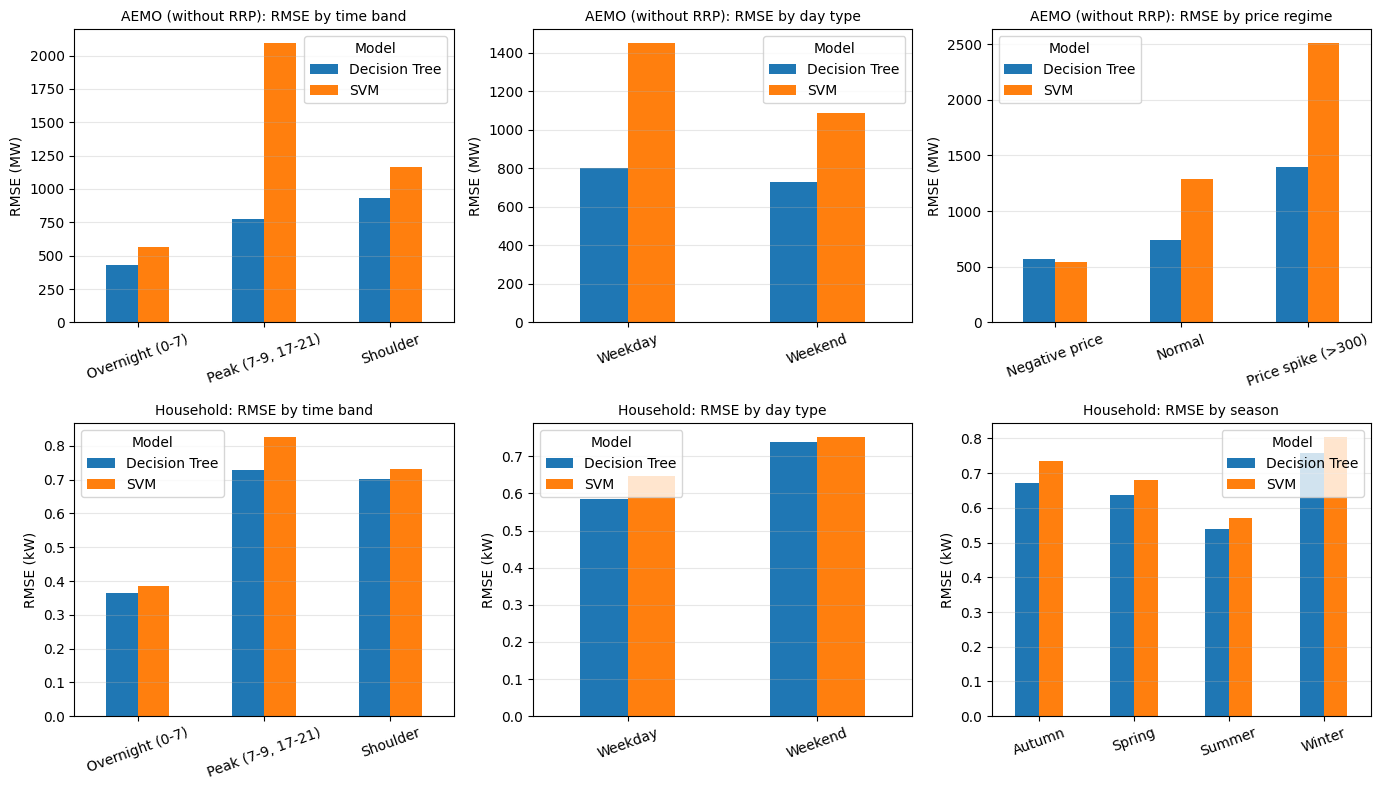

In [8]:
attrs = fair_groups[['Experiment', 'Attribute']].drop_duplicates().values.tolist()
fig, axes = plt.subplots(2, (len(attrs) + 1) // 2, figsize=(14, 8))
for ax, (exp_name, attr) in zip(axes.ravel(), attrs):
    sub = fair_groups[(fair_groups['Experiment'] == exp_name) & (fair_groups['Attribute'] == attr)]
    piv = sub.pivot(index='Group', columns='Model', values='RMSE')
    piv.plot(kind='bar', ax=ax, rot=20)
    ax.set_title(f'{exp_name}: RMSE by {attr.lower()}', fontsize=10)
    ax.set_ylabel('RMSE (MW)' if 'AEMO' in exp_name else 'RMSE (kW)')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
for ax in axes.ravel()[len(attrs):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/fairlearn_rmse_by_group.png', dpi=200); plt.show()

**Reading the tables:** focus on groups with much higher RMSE than others, and on the sign
of the mean error. For an energy retailer, systematic under-forecasting during peaks or price
spikes is the costly direction (buying extra energy at high spot prices). Also check `Count`:
small groups such as price spikes give less reliable estimates and are themselves a
representation issue in the data.